# Matplotlib 프로젝트 - 데이터 시각화 실전 (한국어 폰트 설정)

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib
import platform

# 한국어 폰트 설정
system = platform.system()
if system == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif system == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'Noto Sans CJK JP'

# 음수 기호 표시
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 100

# 기초 프로젝트: 회사 월별 성과 대시보드

**문제:** 회사의 월별 판매, 비용, 이익 데이터를 시각화하세요.

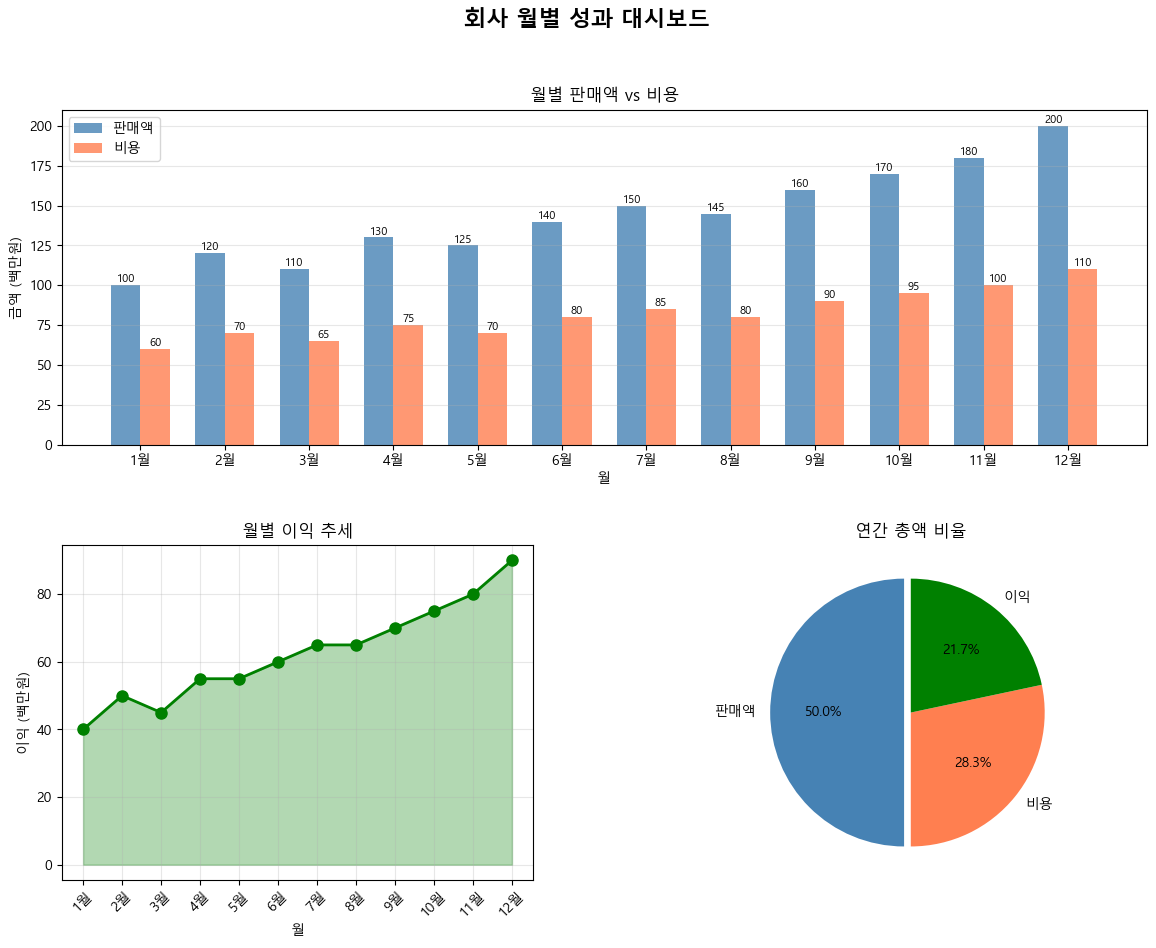

=== 연간 성과 통계 ===
총 판매액: 1730백만원
총 비용: 980백만원
총 이익: 750백만원
이익률: 43.4%
평균 월 판매액: 144.2백만원
월별 이익 표준편차: 14.1백만원


In [12]:
# 데이터 준비
months = ['1월', '2월', '3월', '4월', '5월', '6월', '7월', '8월', '9월', '10월', '11월', '12월']
sales = [100, 120, 110, 130, 125, 140, 150, 145, 160, 170, 180, 200]
costs = [60, 70, 65, 75, 70, 80, 85, 80, 90, 95, 100, 110]
profit = [s - c for s, c in zip(sales, costs)]

fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.3)

# 1. 막대 그래프 - 판매와 비용
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(months))
width = 0.35
bars1 = ax1.bar(x - width/2, sales, width, label='판매액', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, costs, width, label='비용', color='coral', alpha=0.8)

ax1.set_xlabel('월')
ax1.set_ylabel('금액 (백만원)')
ax1.set_title('월별 판매액 vs 비용')
ax1.set_xticks(x)
ax1.set_xticklabels(months)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 값 표시
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

for bar in bars2:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=8)

# 2. 라인 그래프 - 이익 추세
ax2 = fig.add_subplot(gs[1, 0])
ax2.plot(months, profit, marker='o', linewidth=2, markersize=8, color='green')
ax2.fill_between(range(len(months)), profit, alpha=0.3, color='green')
ax2.set_xlabel('월')
ax2.set_ylabel('이익 (백만원)')
ax2.set_title('월별 이익 추세')
ax2.grid(alpha=0.3)
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)

# 3. 원형 그래프 - 연간 총액 비율
ax3 = fig.add_subplot(gs[1, 1])
total_sales = sum(sales)
total_costs = sum(costs)
total_profit = sum(profit)
sizes = [total_sales, total_costs, total_profit]
labels = ['판매액', '비용', '이익']
colors = ['steelblue', 'coral', 'green']
explode = (0.05, 0, 0)
ax3.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', explode=explode, startangle=90)
ax3.set_title('연간 총액 비율')

plt.suptitle('회사 월별 성과 대시보드', fontsize=16, fontweight='bold')
plt.show()

# 통계
print('=== 연간 성과 통계 ===')
print(f'총 판매액: {total_sales}백만원')
print(f'총 비용: {total_costs}백만원')
print(f'총 이익: {total_profit}백만원')
print(f'이익률: {total_profit/total_sales*100:.1f}%')
print(f'평균 월 판매액: {np.mean(sales):.1f}백만원')
print(f'월별 이익 표준편차: {np.std(profit):.1f}백만원')

# 중급 프로젝트: 고객 분석 대시보드

**문제:** 고객의 나이, 구매액, 방문 빈도를 분석하고 시각화하세요.

C:\Users\User\AppData\Local\Temp\ipykernel_13032\243495452.py:70: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_avg = customer_data.groupby('Segment')['Purchase_Amount'].mean()
posx and posy should be finite values
posx and posy should be finite values


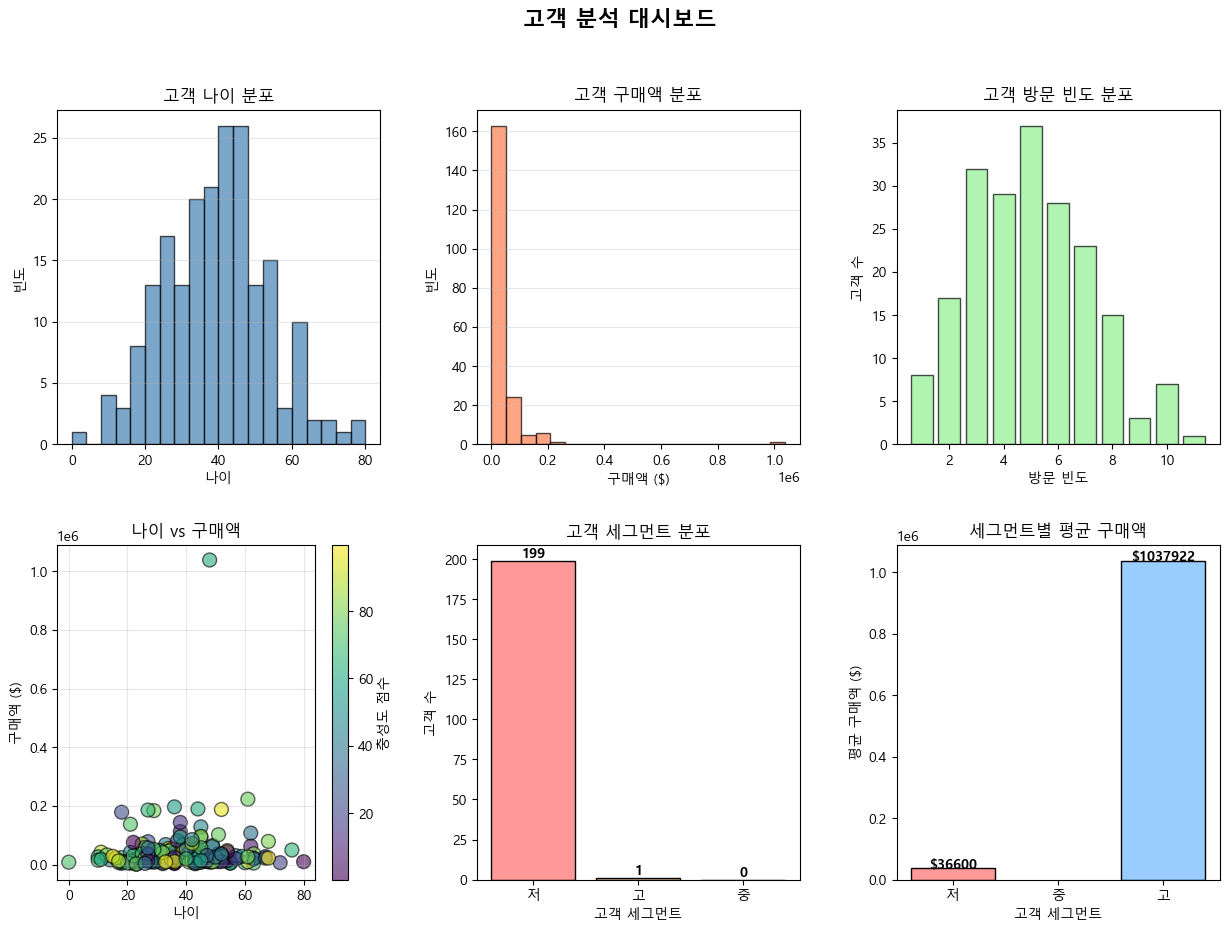

=== 고객 분석 통계 ===
총 고객 수: 200
평균 나이: 38.9세
평균 구매액: $41606.96
평균 방문 빈도: 5.0회

세그먼트별 고객 수:
Segment
저    199
고      1
중      0
Name: count, dtype: int64


In [13]:
# 고객 데이터 생성
np.random.seed(42)
n_customers = 200

customer_data = pd.DataFrame({
    'Age': np.random.normal(40, 15, n_customers).astype(int),
    'Purchase_Amount': np.random.lognormal(10, 1, n_customers),
    'Visit_Frequency': np.random.poisson(5, n_customers),
    'Loyalty_Score': np.random.uniform(0, 100, n_customers)
})

# 고객 세그멘테이션
customer_data['Segment'] = pd.cut(customer_data['Purchase_Amount'], 
                                  bins=3, 
                                  labels=['저', '중', '고'])

fig = plt.figure(figsize=(15, 10))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

# 1. 나이 분포
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(customer_data['Age'], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('나이')
ax1.set_ylabel('빈도')
ax1.set_title('고객 나이 분포')
ax1.grid(axis='y', alpha=0.3)

# 2. 구매액 분포
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(customer_data['Purchase_Amount'], bins=20, color='coral', edgecolor='black', alpha=0.7)
ax2.set_xlabel('구매액 ($)')
ax2.set_ylabel('빈도')
ax2.set_title('고객 구매액 분포')
ax2.grid(axis='y', alpha=0.3)

# 3. 방문 빈도
ax3 = fig.add_subplot(gs[0, 2])
visit_counts = customer_data['Visit_Frequency'].value_counts().sort_index()
ax3.bar(visit_counts.index, visit_counts.values, color='lightgreen', edgecolor='black', alpha=0.7)
ax3.set_xlabel('방문 빈도')
ax3.set_ylabel('고객 수')
ax3.set_title('고객 방문 빈도 분포')

# 4. 산점도 - 나이 vs 구매액
ax4 = fig.add_subplot(gs[1, 0])
scatter = ax4.scatter(customer_data['Age'], customer_data['Purchase_Amount'], 
                      c=customer_data['Loyalty_Score'], cmap='viridis', 
                      s=100, alpha=0.6, edgecolors='black')
ax4.set_xlabel('나이')
ax4.set_ylabel('구매액 ($)')
ax4.set_title('나이 vs 구매액')
plt.colorbar(scatter, ax=ax4, label='충성도 점수')
ax4.grid(alpha=0.3)

# 5. 세그먼트별 분석
ax5 = fig.add_subplot(gs[1, 1])
segment_counts = customer_data['Segment'].value_counts()
colors_seg = ['#ff9999', '#ffcc99', '#99ccff']
ax5.bar(segment_counts.index, segment_counts.values, color=colors_seg, edgecolor='black')
ax5.set_xlabel('고객 세그먼트')
ax5.set_ylabel('고객 수')
ax5.set_title('고객 세그먼트 분포')

# 값 표시
for i, v in enumerate(segment_counts.values):
    ax5.text(i, v + 2, str(v), ha='center', fontweight='bold')

# 6. 세그먼트별 평균 구매액
ax6 = fig.add_subplot(gs[1, 2])
segment_avg = customer_data.groupby('Segment')['Purchase_Amount'].mean()
ax6.bar(segment_avg.index, segment_avg.values, color=colors_seg, edgecolor='black')
ax6.set_xlabel('고객 세그먼트')
ax6.set_ylabel('평균 구매액 ($)')
ax6.set_title('세그먼트별 평균 구매액')

for i, v in enumerate(segment_avg.values):
    ax6.text(i, v + 10, f'${v:.0f}', ha='center', fontweight='bold')

plt.suptitle('고객 분석 대시보드', fontsize=16, fontweight='bold')
plt.show()

# 통계
print('=== 고객 분석 통계 ===')
print(f'총 고객 수: {len(customer_data)}')
print(f'평균 나이: {customer_data["Age"].mean():.1f}세')
print(f'평균 구매액: ${customer_data["Purchase_Amount"].mean():.2f}')
print(f'평균 방문 빈도: {customer_data["Visit_Frequency"].mean():.1f}회')
print(f'\n세그먼트별 고객 수:')
print(customer_data['Segment'].value_counts())

# 상급 프로젝트: 3D 데이터 시각화 및 분석

**문제:** 다차원 데이터를 3D 및 2D 형식으로 시각화하세요.

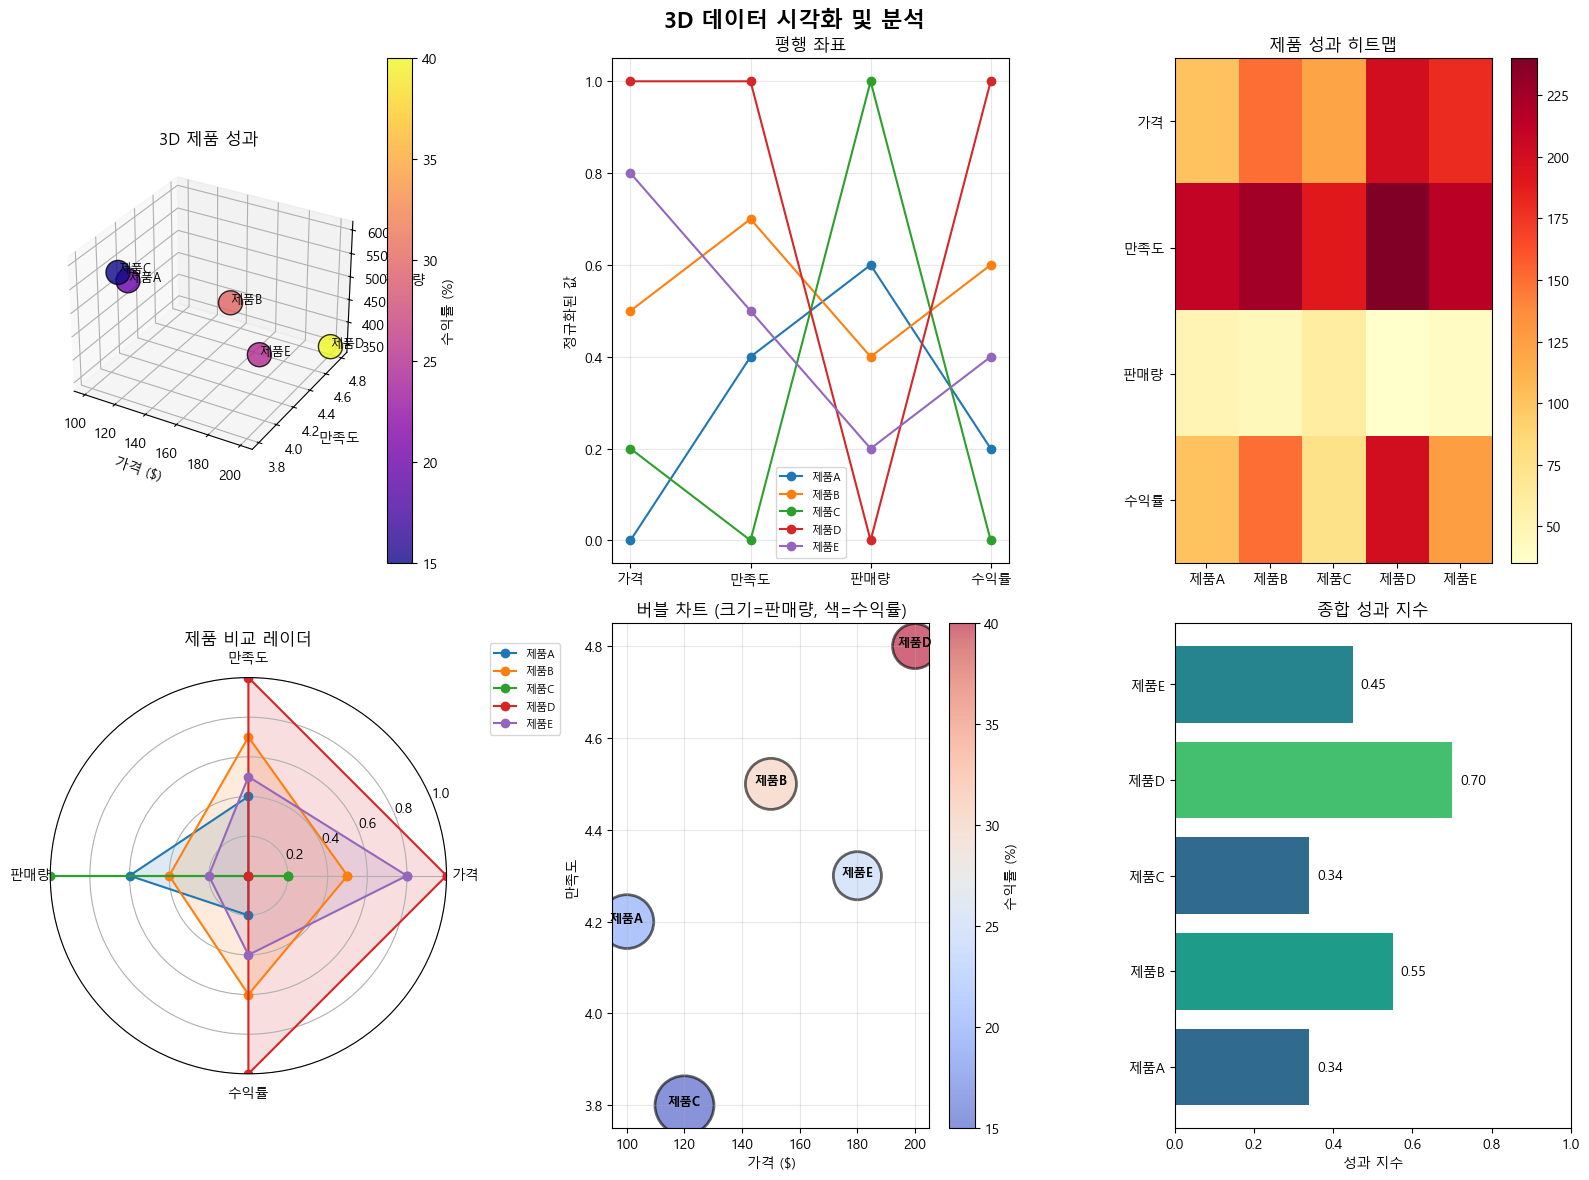

In [14]:
# 3D 데이터 생성 (제품 성능)
np.random.seed(42)
products = ['제품A', '제품B', '제품C', '제품D', '제품E']

# 가격, 만족도, 판매량
price = np.array([100, 150, 120, 200, 180])
satisfaction = np.array([4.2, 4.5, 3.8, 4.8, 4.3])
sales_volume = np.array([500, 450, 600, 350, 400])
profit_margin = np.array([20, 30, 15, 40, 25])

fig = plt.figure(figsize=(16, 12))

# 1. 3D 산점도
ax1 = fig.add_subplot(2, 3, 1, projection='3d')
scatter = ax1.scatter(price, satisfaction, sales_volume, 
                      c=profit_margin, s=300, cmap='plasma', alpha=0.8, edgecolors='black')
ax1.set_xlabel('가격 ($)')
ax1.set_ylabel('만족도')
ax1.set_zlabel('판매량')
ax1.set_title('3D 제품 성과')
plt.colorbar(scatter, ax=ax1, label='수익률 (%)')

# 제품명 표시
for i, txt in enumerate(products):
    ax1.text(price[i], satisfaction[i], sales_volume[i], txt, fontsize=9)

# 2. 평행 좌표
ax2 = fig.add_subplot(2, 3, 2)
# 정규화
norm_price = (price - price.min()) / (price.max() - price.min())
norm_satisfaction = (satisfaction - satisfaction.min()) / (satisfaction.max() - satisfaction.min())
norm_sales = (sales_volume - sales_volume.min()) / (sales_volume.max() - sales_volume.min())
norm_margin = (profit_margin - profit_margin.min()) / (profit_margin.max() - profit_margin.min())

for i in range(len(products)):
    ax2.plot([0, 1, 2, 3], [norm_price[i], norm_satisfaction[i], norm_sales[i], norm_margin[i]], 
            marker='o', label=products[i])

ax2.set_xticks([0, 1, 2, 3])
ax2.set_xticklabels(['가격', '만족도', '판매량', '수익률'])
ax2.set_ylabel('정규화된 값')
ax2.set_title('평행 좌표')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# 3. 히트맵
ax3 = fig.add_subplot(2, 3, 3)
data_matrix = np.array([price, satisfaction*50, sales_volume/10, profit_margin*5])
im = ax3.imshow(data_matrix, cmap='YlOrRd', aspect='auto')
ax3.set_yticks([0, 1, 2, 3])
ax3.set_yticklabels(['가격', '만족도', '판매량', '수익률'])
ax3.set_xticks(range(len(products)))
ax3.set_xticklabels(products)
ax3.set_title('제품 성과 히트맵')
plt.colorbar(im, ax=ax3)

# 4. 레이더 차트
ax4 = fig.add_subplot(2, 3, 4, projection='polar')
angles = np.linspace(0, 2*np.pi, 4, endpoint=False).tolist()
angles += angles[:1]

for i, product in enumerate(products):
    values = [norm_price[i], norm_satisfaction[i], norm_sales[i], norm_margin[i]]
    values += values[:1]
    ax4.plot(angles, values, marker='o', label=product)
    ax4.fill(angles, values, alpha=0.15)

ax4.set_xticks(angles[:-1])
ax4.set_xticklabels(['가격', '만족도', '판매량', '수익률'])
ax4.set_ylim(0, 1)
ax4.set_title('제품 비교 레이더')
ax4.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)
ax4.grid(True)

# 5. 버블 차트
ax5 = fig.add_subplot(2, 3, 5)
bubble = ax5.scatter(price, satisfaction, s=sales_volume*3, c=profit_margin, 
                     cmap='coolwarm', alpha=0.6, edgecolors='black', linewidth=2)
ax5.set_xlabel('가격 ($)')
ax5.set_ylabel('만족도')
ax5.set_title('버블 차트 (크기=판매량, 색=수익률)')

for i, txt in enumerate(products):
    ax5.annotate(txt, (price[i], satisfaction[i]), ha='center', fontsize=9, fontweight='bold')

plt.colorbar(bubble, ax=ax5, label='수익률 (%)')
ax5.grid(alpha=0.3)

# 6. 종합 성과 지수
ax6 = fig.add_subplot(2, 3, 6)
performance_index = norm_price * 0.2 + norm_satisfaction * 0.3 + norm_sales * 0.3 + norm_margin * 0.2
bars = ax6.barh(products, performance_index, color=plt.cm.viridis(performance_index))
ax6.set_xlabel('성과 지수')
ax6.set_title('종합 성과 지수')
ax6.set_xlim(0, 1)

for i, (bar, val) in enumerate(zip(bars, performance_index)):
    ax6.text(val + 0.02, i, f'{val:.2f}', va='center')

plt.suptitle('3D 데이터 시각화 및 분석', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# 고급 프로젝트: 인터랙티브 대시보드 (정적 버전)

**문제:** 다양한 통계 차트를 포함한 종합 대시보드를 만드세요.

C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 12304 (\N{LEFT BLACK LENTICULAR BRACKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 45380 (\N{HANGUL SYLLABLE NYEON}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\User\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51648 (\N{HANGUL SYLLABLE 

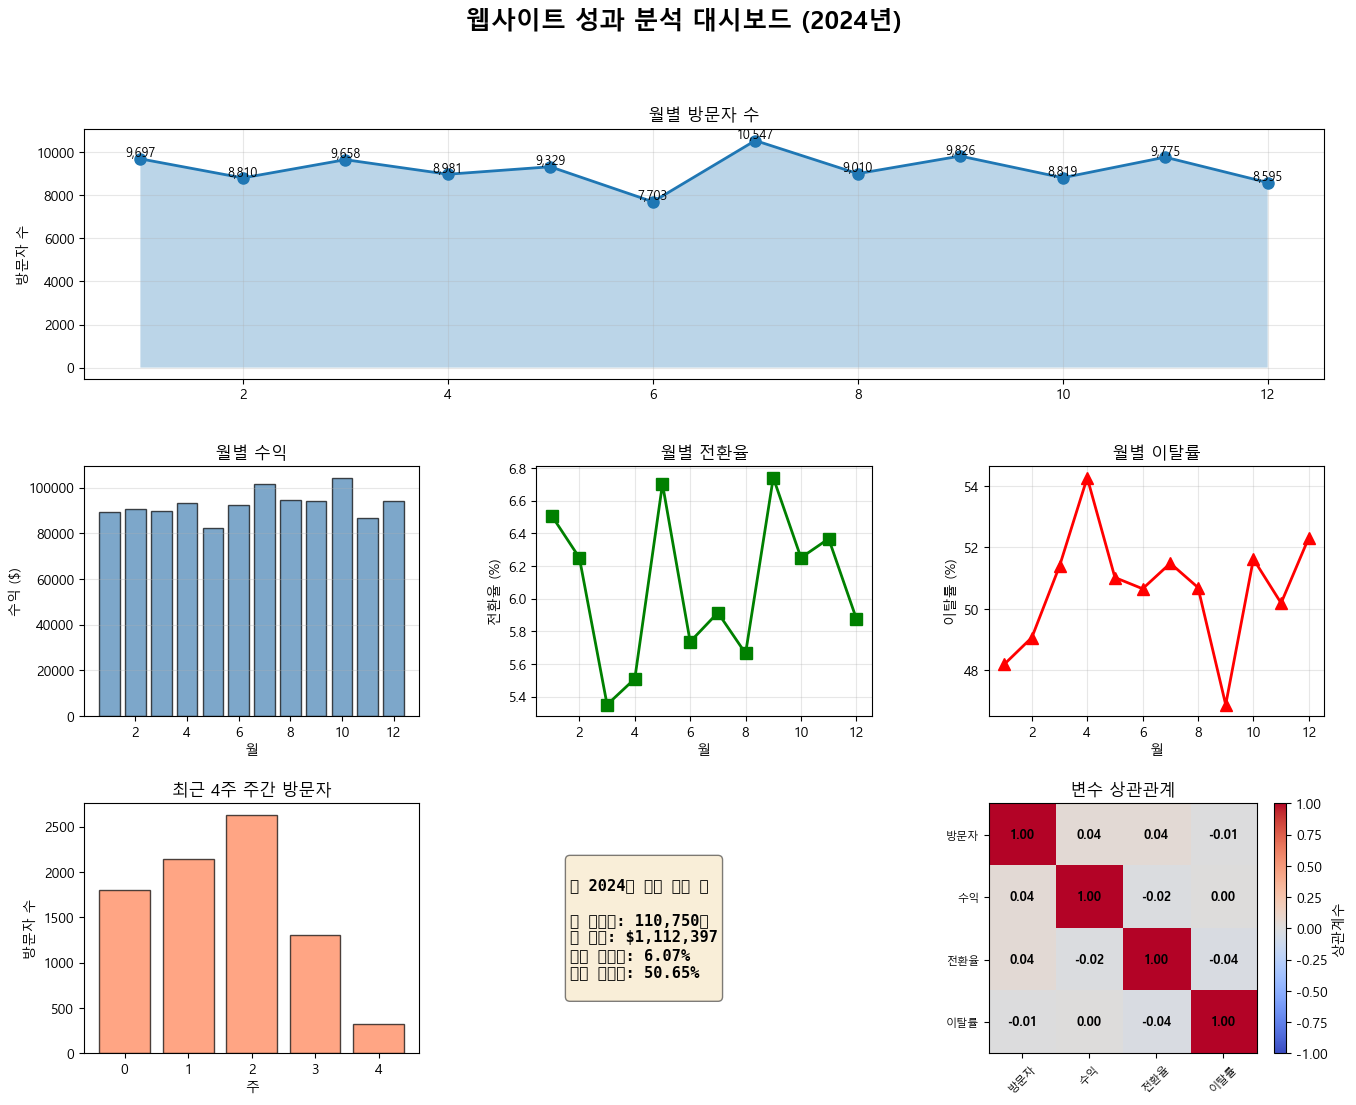


=== 년도 전체 성과 요약 ===
총 방문자: 110,750명
총 수익: $1,112,397
평균 일일 방문자: 303명
평균 일일 수익: $3047.66
전환율 범위: 2.02% ~ 9.98%
이탈률 범위: 30.01% ~ 69.97%


In [15]:
# 종합 데이터 생성
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=365, freq='D')
daily_data = pd.DataFrame({
    'Date': dates,
    'Visitors': np.random.randint(100, 500, 365),
    'Revenue': np.random.randint(1000, 5000, 365),
    'Conversion': np.random.uniform(0.02, 0.1, 365),
    'Bounce_Rate': np.random.uniform(0.3, 0.7, 365)
})

# 월별 집계
daily_data['Month'] = daily_data['Date'].dt.month
monthly_data = daily_data.groupby('Month').agg({
    'Visitors': 'sum',
    'Revenue': 'sum',
    'Conversion': 'mean',
    'Bounce_Rate': 'mean'
})

fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.35)

# 제목
fig.suptitle('웹사이트 성과 분석 대시보드 (2024년)', fontsize=18, fontweight='bold', y=0.98)

# 1. 월별 방문자 수
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(monthly_data.index, monthly_data['Visitors'], marker='o', linewidth=2, markersize=8, label='방문자')
ax1.fill_between(monthly_data.index, monthly_data['Visitors'], alpha=0.3)
ax1.set_ylabel('방문자 수')
ax1.set_title('월별 방문자 수')
ax1.grid(alpha=0.3)

for x, y in zip(monthly_data.index, monthly_data['Visitors']):
    ax1.text(x, y+100, f'{int(y):,}', ha='center', fontsize=9)

# 2. 월별 수익
ax2 = fig.add_subplot(gs[1, 0])
ax2.bar(monthly_data.index, monthly_data['Revenue'], color='steelblue', alpha=0.7, edgecolor='black')
ax2.set_xlabel('월')
ax2.set_ylabel('수익 ($)')
ax2.set_title('월별 수익')
ax2.grid(axis='y', alpha=0.3)

# 3. 전환율 추이
ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(monthly_data.index, monthly_data['Conversion']*100, marker='s', 
        linewidth=2, markersize=8, color='green')
ax3.set_xlabel('월')
ax3.set_ylabel('전환율 (%)')
ax3.set_title('월별 전환율')
ax3.grid(alpha=0.3)

# 4. 이탈률
ax4 = fig.add_subplot(gs[1, 2])
ax4.plot(monthly_data.index, monthly_data['Bounce_Rate']*100, marker='^', 
        linewidth=2, markersize=8, color='red')
ax4.set_xlabel('월')
ax4.set_ylabel('이탈률 (%)')
ax4.set_title('월별 이탈률')
ax4.grid(alpha=0.3)

# 5. 주간 성과 (최근 4주)
ax5 = fig.add_subplot(gs[2, 0])
recent_data = daily_data.tail(28)
weekly_visitors = recent_data.groupby(recent_data.index // 7)['Visitors'].sum()
ax5.bar(range(len(weekly_visitors)), weekly_visitors.values, color='coral', alpha=0.7, edgecolor='black')
ax5.set_xlabel('주')
ax5.set_ylabel('방문자 수')
ax5.set_title('최근 4주 주간 방문자')

# 6. KPI 카드 스타일
ax6 = fig.add_subplot(gs[2, 1])
ax6.axis('off')
total_visitors = daily_data['Visitors'].sum()
total_revenue = daily_data['Revenue'].sum()
avg_conversion = daily_data['Conversion'].mean()
avg_bounce = daily_data['Bounce_Rate'].mean()

metrics_text = f"""
【 2024년 주요 지표 】

총 방문자: {total_visitors:,}명
총 수익: ${total_revenue:,}
평균 전환율: {avg_conversion*100:.2f}%
평균 이탈률: {avg_bounce*100:.2f}%
"""

ax6.text(0.1, 0.5, metrics_text, fontsize=11, verticalalignment='center',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
        family='monospace', fontweight='bold')

# 7. 상관관계 분석
ax7 = fig.add_subplot(gs[2, 2])
corr_data = daily_data[['Visitors', 'Revenue', 'Conversion', 'Bounce_Rate']].corr()
im = ax7.imshow(corr_data, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
ax7.set_xticks(range(4))
ax7.set_yticks(range(4))
ax7.set_xticklabels(['방문자', '수익', '전환율', '이탈률'], fontsize=8, rotation=45)
ax7.set_yticklabels(['방문자', '수익', '전환율', '이탈률'], fontsize=8)
ax7.set_title('변수 상관관계')

for i in range(4):
    for j in range(4):
        text = ax7.text(j, i, f'{corr_data.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontweight='bold', fontsize=9)

plt.colorbar(im, ax=ax7, label='상관계수')

plt.show()

print('\n=== 년도 전체 성과 요약 ===')
print(f'총 방문자: {total_visitors:,}명')
print(f'총 수익: ${total_revenue:,}')
print(f'평균 일일 방문자: {total_visitors/365:.0f}명')
print(f'평균 일일 수익: ${total_revenue/365:.2f}')
print(f'전환율 범위: {daily_data["Conversion"].min()*100:.2f}% ~ {daily_data["Conversion"].max()*100:.2f}%')
print(f'이탈률 범위: {daily_data["Bounce_Rate"].min()*100:.2f}% ~ {daily_data["Bounce_Rate"].max()*100:.2f}%')